In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = "/content/drive/MyDrive/Soil_Project"
os.makedirs(PROJECT_DIR, exist_ok=True)

print("Project folder ready:", PROJECT_DIR)

Mounted at /content/drive
Project folder ready: /content/drive/MyDrive/Soil_Project


In [7]:
from google.colab import files

uploaded = files.upload()

Saving CyAUG-Dataset.zip to CyAUG-Dataset.zip


In [8]:
import shutil
import os

SOURCE = "/content/CyAUG-Dataset.zip"
DEST = "/content/drive/MyDrive/Soil_Project/CyAUG-Dataset.zip"

shutil.copy2(SOURCE, DEST)

print("Saved permanently to Drive:", os.path.exists(DEST))

Saved permanently to Drive: True


In [9]:
import zipfile
import os

ZIP_PATH = "/content/drive/MyDrive/Soil_Project/CyAUG-Dataset.zip"
EXTRACT_PATH = "/content/CyAUG-Dataset"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Extraction completed!")
print(os.listdir(EXTRACT_PATH))

Extraction completed!
['CyAUG-Dataset']


In [10]:
import os

DATASET_PATH = "/content/CyAUG-Dataset/CyAUG-Dataset"

classes = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print("Number of classes:", len(classes))
print("Classes:")
for i, cls in enumerate(classes):
    print(i, cls)

Number of classes: 7
Classes:
0 Alluvial_Soil
1 Arid_Soil
2 Black_Soil
3 Laterite_Soil
4 Mountain_Soil
5 Red_Soil
6 Yellow_Soil


In [11]:
import os

for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)
    count = len([
        f for f in os.listdir(folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ])
    print(f"{cls}: {count} images")

Alluvial_Soil: 692 images
Arid_Soil: 284 images
Black_Soil: 1173 images
Laterite_Soil: 219 images
Mountain_Soil: 201 images
Red_Soil: 1126 images
Yellow_Soil: 1401 images


In [1]:

!nvidia-smi

Mon Sep 14 12:12:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

ZIP_PATH = "/content/drive/MyDrive/Soil_Project/CyAUG-Dataset.zip"

print("ZIP exists:", os.path.exists(ZIP_PATH))

ZIP exists: True


In [7]:
import zipfile
import os

ZIP_PATH = "/content/drive/MyDrive/Soil_Project/CyAUG-Dataset.zip"
EXTRACT_PATH = "/content/CyAUG-Dataset"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Extraction completed!")
print(os.listdir(EXTRACT_PATH))

Extraction completed!
['CyAUG-Dataset']


In [8]:
DATASET_PATH = "/content/CyAUG-Dataset/CyAUG-Dataset"

print("Dataset exists:", os.path.exists(DATASET_PATH))
print("Classes:", sorted(os.listdir(DATASET_PATH)))

Dataset exists: True
Classes: ['Alluvial_Soil', 'Arid_Soil', 'Black_Soil', 'Laterite_Soil', 'Mountain_Soil', 'Red_Soil', 'Yellow_Soil']


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.20,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED,
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED,
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 4080 images belonging to 7 classes.
Found 1016 images belonging to 7 classes.
Class indices: {'Alluvial_Soil': 0, 'Arid_Soil': 1, 'Black_Soil': 2, 'Laterite_Soil': 3, 'Mountain_Soil': 4, 'Red_Soil': 5, 'Yellow_Soil': 6}


In [10]:
#build res50
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the ResNet50 base
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(7, activation="softmax")
])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

PROJECT_DIR = "/content/drive/MyDrive/Soil_Project"

BEST_MODEL_PATH = os.path.join(
    PROJECT_DIR, "best_soil_resnet50.keras"
)

FINAL_MODEL_PATH = os.path.join(
    PROJECT_DIR, "soil_resnet50_model.keras"
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

print("Best model will be saved to:")
print(BEST_MODEL_PATH)

Best model will be saved to:
/content/drive/MyDrive/Soil_Project/best_soil_resnet50.keras


In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.5747 - loss: 1.2714
Epoch 1: val_accuracy improved from None to 0.87894, saving model to /content/drive/MyDrive/Soil_Project/best_soil_resnet50.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Soil_Project/best_soil_resnet50.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 100s 677ms/step - accuracy: 0.7365 - loss: 0.8189 - val_accuracy: 0.8789 - val_loss: 0.4052 - learning_rate: 1.0000e-04
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.9014 - loss: 0.3326
Epoch 2: val_accuracy improved from 0.87894 to 0.89272, saving model to /content/drive/MyDrive/Soil_Project/best_soil_resnet50.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Soil_Project/best_soil_resnet50.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 75s 583ms/step - accuracy: 0.9123 - loss: 0.2968 - val_accuracy: 0.8927 - val_loss: 0.3269 - learning_rate: 1.0000e-04
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.9431

In [14]:
model.save(FINAL_MODEL_PATH)

print("Final model saved successfully!")
print("Location:", FINAL_MODEL_PATH)

Final model saved successfully!
Location: /content/drive/MyDrive/Soil_Project/soil_resnet50_model.keras


In [15]:
import os

print("Best model exists:", os.path.exists(BEST_MODEL_PATH))
print("Final model exists:", os.path.exists(FINAL_MODEL_PATH))

Best model exists: True
Final model exists: True


In [16]:
val_loss, val_accuracy = model.evaluate(val_generator)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 467ms/step - accuracy: 0.9026 - loss: 0.3192
Validation Loss: 0.3191725015640259
Validation Accuracy: 0.9025590419769287


In [17]:
import numpy as np
from sklearn.metrics import classification_report

# Reset validation generator
val_generator.reset()

# Generate predictions
predictions = model.predict(val_generator)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

# Get class names
class_names = list(val_generator.class_indices.keys())

# Classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 609ms/step
               precision    recall  f1-score   support

Alluvial_Soil       0.81      0.83      0.82       138
    Arid_Soil       0.60      0.88      0.71        56
   Black_Soil       0.97      0.97      0.97       234
Laterite_Soil       0.51      0.79      0.62        43
Mountain_Soil       1.00      0.65      0.79        40
     Red_Soil       0.97      0.94      0.95       225
  Yellow_Soil       0.99      0.88      0.93       280

     accuracy                           0.89      1016
    macro avg       0.84      0.85      0.83      1016
 weighted avg       0.92      0.89      0.90      1016



<Figure size 800x800 with 0 Axes>

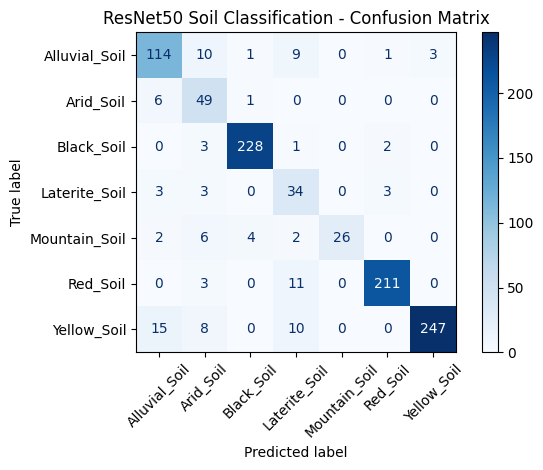

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("ResNet50 Soil Classification - Confusion Matrix")
plt.tight_layout()
plt.show()

In [19]:
import numpy as np

# Find incorrect predictions
incorrect_indices = np.where(y_true != y_pred)[0]

print("Total validation images:", len(y_true))
print("Incorrect predictions:", len(incorrect_indices))
print("Correct predictions:", len(y_true) - len(incorrect_indices))
print("Error rate:", len(incorrect_indices) / len(y_true))

Total validation images: 1016
Incorrect predictions: 107
Correct predictions: 909
Error rate: 0.10531496062992125


In [20]:
from collections import Counter

confusions = []

for i in incorrect_indices:
    actual = class_names[y_true[i]]
    predicted = class_names[y_pred[i]]
    confusions.append((actual, predicted))

confusion_counts = Counter(confusions)

print("Most common incorrect predictions:\n")

for (actual, predicted), count in confusion_counts.most_common(10):
    print(f"{actual} → {predicted}: {count}")

Most common incorrect predictions:

Yellow_Soil → Alluvial_Soil: 15
Red_Soil → Laterite_Soil: 11
Alluvial_Soil → Arid_Soil: 10
Yellow_Soil → Laterite_Soil: 10
Alluvial_Soil → Laterite_Soil: 9
Yellow_Soil → Arid_Soil: 8
Arid_Soil → Alluvial_Soil: 6
Mountain_Soil → Arid_Soil: 6
Mountain_Soil → Black_Soil: 4
Alluvial_Soil → Yellow_Soil: 3


In [21]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Soil_Project"

BEST_MODEL_PATH = os.path.join(
    PROJECT_DIR, "best_soil_resnet50.keras"
)

FINAL_MODEL_PATH = os.path.join(
    PROJECT_DIR, "soil_resnet50_model.keras"
)

print("Best model exists:", os.path.exists(BEST_MODEL_PATH))
print("Final model exists:", os.path.exists(FINAL_MODEL_PATH))

if os.path.exists(BEST_MODEL_PATH):
    print("Best model size:", round(os.path.getsize(BEST_MODEL_PATH) / (1024**2), 2), "MB")

if os.path.exists(FINAL_MODEL_PATH):
    print("Final model size:", round(os.path.getsize(FINAL_MODEL_PATH) / (1024**2), 2), "MB")

Best model exists: True
Final model exists: True
Best model size: 96.63 MB
Final model size: 96.63 MB


In [22]:
import pandas as pd
import os

# Classification report as a dictionary
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

REPORT_PATH = "/content/drive/MyDrive/Soil_Project/ResNet50_classification_report.csv"

report_df.to_csv(REPORT_PATH)

print("Classification report saved!")
print(REPORT_PATH)

Classification report saved!
/content/drive/MyDrive/Soil_Project/ResNet50_classification_report.csv


In [23]:
CM_PATH = "/content/drive/MyDrive/Soil_Project/ResNet50_confusion_matrix.csv"

pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
).to_csv(CM_PATH)

print("Confusion matrix saved!")
print(CM_PATH)

Confusion matrix saved!
/content/drive/MyDrive/Soil_Project/ResNet50_confusion_matrix.csv
